# **Activation functions**



In [1]:
# Imports math library
import numpy as np
# Imports plotting library
import matplotlib.pyplot as plt

In [12]:
# Plot the shallow neural network. Inputs are in range [0,1] and output [-1,1]
# If the flag is set to true then all the intermediate stages are drawn
def plot_neural_network(x, y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3, plot_all=False):
    
    # Plot intermediate plots if flag set
    if plot_all:
        fig, ax = plt.subplots(3,3)
        fig.set_size_inches(8.5, 8.5)
        fig.tight_layout(pad=3.0)
        ax[0,0].plot(x,pre_1,'r-'); ax[0,0].set_ylabel('Preactivation')
        ax[0,1].plot(x,pre_2,'b-'); ax[0,1].set_ylabel('Preactivation')
        ax[0,2].plot(x,pre_3,'g-'); ax[0,2].set_ylabel('Preactivation')
        ax[1,0].plot(x,act_1,'r-'); ax[1,0].set_ylabel('Activation')
        ax[1,1].plot(x,act_2,'b-'); ax[1,1].set_ylabel('Activation')
        ax[1,2].plot(x,act_3,'g-'); ax[1,2].set_ylabel('Activation')
        ax[2,0].plot(x,w_act_1,'r-'); ax[2,0].set_ylabel('Weighted Act')
        ax[2,1].plot(x,w_act_2,'b-'); ax[2,1].set_ylabel('Weighted Act')
        ax[2,2].plot(x,w_act_3,'g-'); ax[2,2].set_ylabel('Weighted Act')

        for plot_y in range(3):
            for plot_x in range(3):
                ax[plot_y,plot_x].set_xlim([0,1])
                ax[plot_x,plot_y].set_ylim([-1,1])
                ax[plot_y,plot_x].set_aspect(0.5)
            ax[2,plot_y].set_xlabel('Input, $x$')
        plt.show()

    fig, ax = plt.subplots()
    ax.plot(x,y)
    ax.set_xlabel('Input, $x$'); ax.set_ylabel('Output, $y$')
    ax.set_xlim([0,1]);ax.set_ylim([-1,1])
    ax.set_aspect(0.5)
    plt.show()

In [13]:
# Define a shallow neural network with, one input, one output, and three hidden units
def shallow_net(x, activation_fn, phi_0,phi_1,phi_2,phi_3, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31):
  pre_1 = theta_10 + theta_11 * x
  pre_2 = theta_20 + theta_21 * x
  pre_3 = theta_30 + theta_31 * x
  # Pass these through the ReLU function to compute the activations

  act_1 = activation_fn(pre_1)
  act_2 = activation_fn(pre_2)
  act_3 = activation_fn(pre_3)

  w_act_1 = phi_1 * act_1
  w_act_2 = phi_2 * act_2
  w_act_3 = phi_3 * act_3

  y = phi_0 + w_act_1 + w_act_2 + w_act_3

  # Return all variables
  return y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3

In [14]:
# Define the Rectified Linear Unit (ReLU) function
def ReLU(preactivation):
    preactivation = np.array(preactivation)  # Convert to NumPy array
    activation = preactivation.clip(0.0)
    return activation

First, let's run the network with a ReLU functions

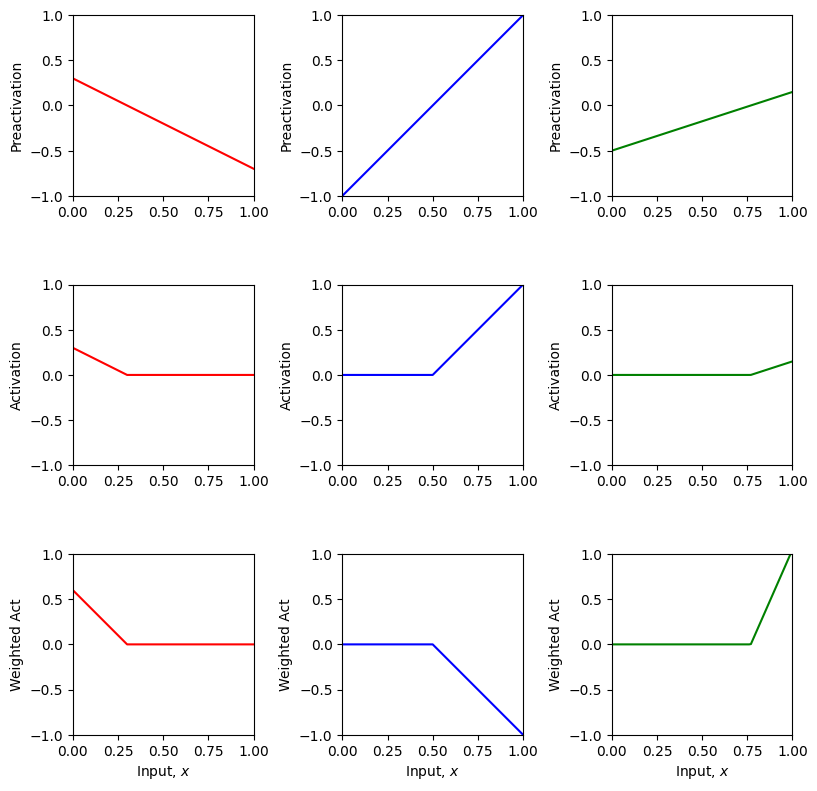

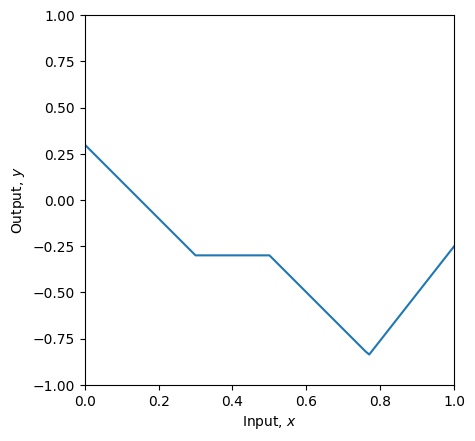

In [16]:
# Now lets define some parameters and run the neural network
theta_10 =  0.3 ; theta_11 = -1.0
theta_20 = -1.0  ; theta_21 = 2.0
theta_30 = -0.5  ; theta_31 = 0.65
phi_0 = -0.3; phi_1 = 2.0; phi_2 = -1.0; phi_3 = 7.0

# Define a range of input values
x = np.arange(0, 1.01, 0.01)
y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3=shallow_net(x, ReLU, phi_0,phi_1,phi_2,phi_3, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31)
plot_neural_network(x, y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3,True)

# Sigmoid activation function

A logistic sigmoid function is defined by the equation

\begin{equation}
f[z] = \frac{1}{1+\exp{[-10 z ]}}
\end{equation}



In [17]:
# Define the sigmoid function
def sigmoid(preactivation):
    activation = 1 / (1 + np.exp(-preactivation))
    return activation

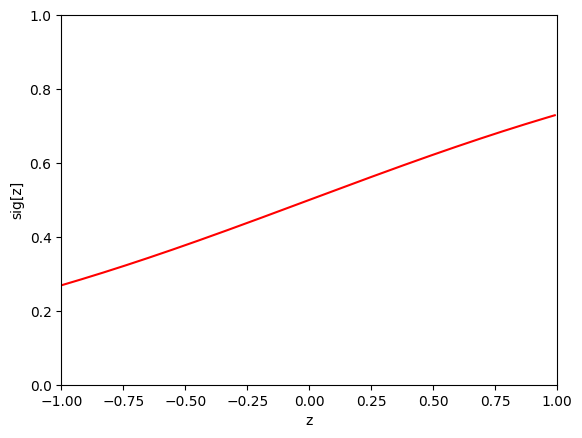

In [18]:
# Make an array of inputs
z = np.arange(-1,1,0.01)
sig_z = sigmoid(z)

# Plot the sigmoid function
fig, ax = plt.subplots()
ax.plot(z,sig_z,'r-')
ax.set_xlim([-1,1]);ax.set_ylim([0,1])
ax.set_xlabel('z'); ax.set_ylabel('sig[z]')
plt.show()

Let's see what happens when we use this activation function in a neural network

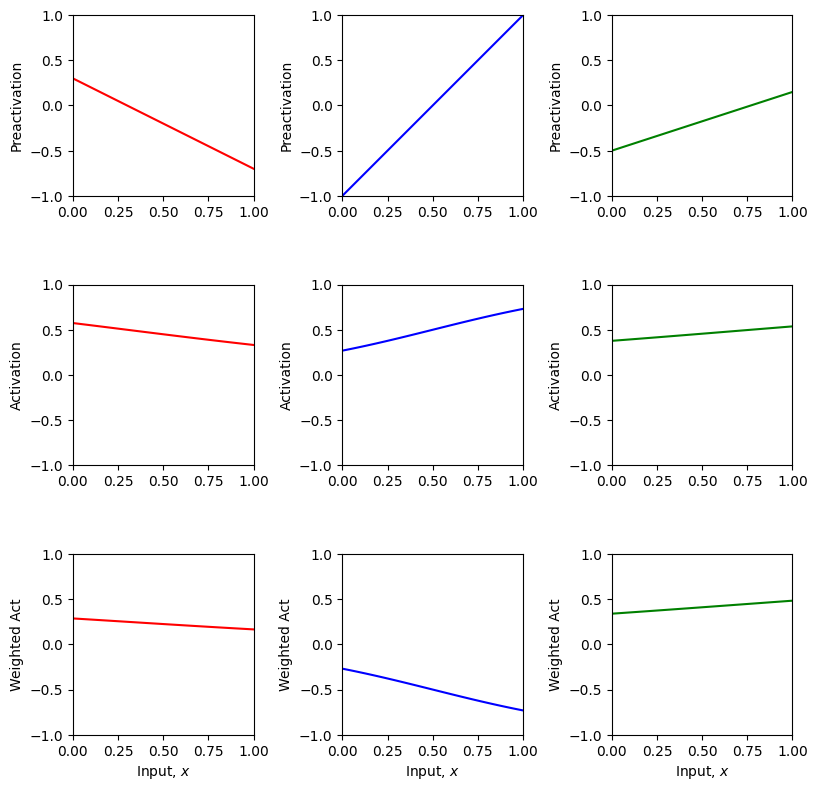

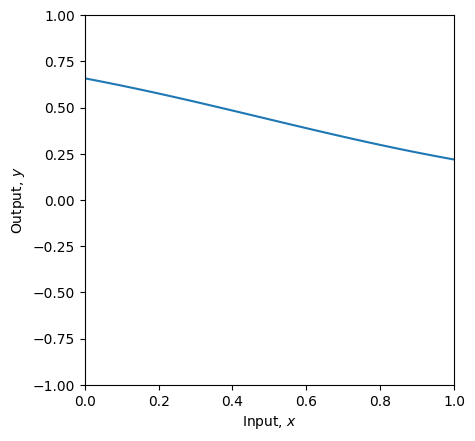

In [19]:
theta_10 =  0.3 ; theta_11 = -1.0
theta_20 = -1.0  ; theta_21 = 2.0
theta_30 = -0.5  ; theta_31 = 0.65
phi_0 = 0.3; phi_1 = 0.5; phi_2 = -1.0; phi_3 = 0.9

y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3=shallow_net(x, sigmoid, phi_0,phi_1,phi_2,phi_3, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31)
plot_neural_network(x, y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3,True)